# Cas9 DMS Activity Prediction
## Step 3 — Baseline Models

### Objective

Establish simple predictive baselines before introducing pretrained protein
sequence representations.

The main target is `DMS_score`, which is a continuous activity-related
phenotype from the Cas9 deep mutational scanning assay.

We evaluate every baseline under two protocols:

1. Position-held-out split
   - Test positions are completely unseen during training.
   - Primary evaluation.

2. Random mutation split
   - Different mutations from the same position may occur in different
     splits.
   - Secondary interpolation evaluation.

The baseline experiments establish how much predictive information is present
in simple mutation-level features before using pretrained protein models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from scipy.stats import pearsonr, spearmanr

SEED = 42

In [2]:
def find_project_root(start_path):
    start_path = Path(start_path).resolve()

    for path in [start_path, *start_path.parents]:
        if (path / "data").is_dir() and (path / "notebooks").is_dir():
            return path

    raise FileNotFoundError(
        "Could not find Mandrake-Bio project root."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

print("Project root:", PROJECT_ROOT)
print("Results directory:", RESULTS_DIR)

Project root: C:\Users\subha\OneDrive\Desktop\Mandrake_Ai_Bio_research\Mandrake_Cas9_Assignment_Pack\Mandrake-Bio
Results directory: C:\Users\subha\OneDrive\Desktop\Mandrake_Ai_Bio_research\Mandrake_Cas9_Assignment_Pack\Mandrake-Bio\results


In [4]:
PROCESSED_DATA_PATH = (
    RESULTS_DIR / "processed_cas9_dms.csv"
)

df = pd.read_csv(PROCESSED_DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (8117, 7)


,mutant,mutated_sequence,DMS_score,DMS_score_bin,wt_residue,position,mutant_residue
0,A1023D,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,-0.620198,0,A,1023,D
1,A1023G,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,-0.424130,0,A,1023,G
2,A1023P,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,-0.626792,0,A,1023,P
3,A1023S,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,-0.490423,0,A,1023,S
4,A1023T,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,-0.543741,0,A,1023,T


In [6]:
POSITION_SPLIT_PATH = (
    RESULTS_DIR / "position_split_assignments.csv"
)

RANDOM_SPLIT_PATH = (
    RESULTS_DIR / "random_split_assignments.csv"
)

position_splits = pd.read_csv(POSITION_SPLIT_PATH)
random_splits = pd.read_csv(RANDOM_SPLIT_PATH)

print("Position split:")
display(position_splits.head())

print("\nRandom split:")
display(random_splits.head())

Position split:


,mutant,position,split
0,A1023D,1023,test
1,A1023G,1023,test
2,A1023P,1023,test
3,A1023S,1023,test
4,A1023T,1023,test



Random split:


,mutant,position,split
0,A1023D,1023,train
1,A1023G,1023,test
2,A1023P,1023,train
3,A1023S,1023,train
4,A1023T,1023,test


In [7]:
df_position = df.merge(
    position_splits[["mutant", "split"]],
    on="mutant",
    how="inner"
)

train_pos = df_position[
    df_position["split"] == "train"
].copy()

val_pos = df_position[
    df_position["split"] == "validation"
].copy()

test_pos = df_position[
    df_position["split"] == "test"
].copy()

print("Position-held-out:")
print("Train:", len(train_pos))
print("Validation:", len(val_pos))
print("Test:", len(test_pos))

Position-held-out:
Train: 6490
Validation: 810
Test: 817


In [8]:
df_random = df.merge(
    random_splits[["mutant", "split"]],
    on="mutant",
    how="inner"
)

train_rand = df_random[
    df_random["split"] == "train"
].copy()

val_rand = df_random[
    df_random["split"] == "validation"
].copy()

test_rand = df_random[
    df_random["split"] == "test"
].copy()

print("Random split:")
print("Train:", len(train_rand))
print("Validation:", len(val_rand))
print("Test:", len(test_rand))

Random split:
Train: 6493
Validation: 812
Test: 812


In [10]:
for frame in [
    train_pos, val_pos, test_pos,
    train_rand, val_rand, test_rand
]:
    frame["substitution"] = (
        frame["wt_residue"]
        + "->"
        + frame["mutant_residue"]
    )

In [11]:
display(
    train_pos[
        [
            "mutant",
            "wt_residue",
            "position",
            "mutant_residue",
            "substitution",
            "DMS_score"
        ]
    ].head(10)
)

,mutant,wt_residue,position,mutant_residue,substitution,DMS_score
6,A1032D,A,1032,D,A->D,-0.104925
7,A1032G,A,1032,G,A->G,-0.055298
8,A1032P,A,1032,P,A->P,-1.473927
9,A1032S,A,1032,S,A->S,-0.198013
10,A1032T,A,1032,T,A->T,1.710928
11,A1032V,A,1032,V,A->V,-0.368924
12,A1034D,A,1034,D,A->D,0.372312
13,A1034G,A,1034,G,A->G,-0.874441
14,A1034P,A,1034,P,A->P,-0.130606
15,A1034S,A,1034,S,A->S,-0.474870


In [12]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    pearson = pearsonr(
        y_true,
        y_pred
    ).statistic

    spearman = spearmanr(
        y_true,
        y_pred
    ).statistic

    return {
        "RMSE": rmse,
        "MAE": mae,
        "Pearson": pearson,
        "Spearman": spearman,
        "R2": r2
    }

In [13]:
def mean_baseline(train_df, eval_df):
    mean_score = train_df["DMS_score"].mean()

    predictions = np.full(
        len(eval_df),
        mean_score
    )

    metrics = regression_metrics(
        eval_df["DMS_score"],
        predictions
    )

    return mean_score, predictions, metrics

In [14]:
mean_value, mean_val_pred, mean_val_metrics = mean_baseline(
    train_pos,
    val_pos
)

print("Training mean:", mean_value)

print("\nValidation metrics:")
for key, value in mean_val_metrics.items():
    print(f"{key}: {value:.4f}")

Training mean: -0.2554126646302442

Validation metrics:
RMSE: 0.5931
MAE: 0.4108
Pearson: nan
Spearman: nan
R2: -0.0028


C:\Users\subha\AppData\Local\Temp\ipykernel_23400\1834933328.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = pearsonr(
C:\Users\subha\AppData\Local\Temp\ipykernel_23400\1834933328.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman = spearmanr(


In [15]:
mean_value = train_pos["DMS_score"].mean()

mean_test_pred = np.full(
    len(test_pos),
    mean_value
)

mean_test_metrics = regression_metrics(
    test_pos["DMS_score"],
    mean_test_pred
)

print("Primary test — Mean baseline")

for key, value in mean_test_metrics.items():
    print(f"{key}: {value:.4f}")

Primary test — Mean baseline
RMSE: 0.5855
MAE: 0.3968
Pearson: nan
Spearman: nan
R2: -0.0000


C:\Users\subha\AppData\Local\Temp\ipykernel_23400\1834933328.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson = pearsonr(
C:\Users\subha\AppData\Local\Temp\ipykernel_23400\1834933328.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman = spearmanr(


## Baseline 0 — Global Mean

The global-mean baseline predicts the mean DMS score observed in the training
set for every test mutation.

This establishes the minimum reference point for the regression task.

Any useful model should improve upon this baseline on held-out data.

In [16]:
def build_substitution_model(alpha=1.0):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "substitution",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                ["substitution"]
            )
        ]
    )

    model = Pipeline(
        steps=[
            ("features", preprocessor),
            ("regressor", Ridge(alpha=alpha))
        ]
    )

    return model

In [18]:
substitution_model = build_substitution_model(
    alpha=1.0
)

substitution_model.fit(
    train_pos[["substitution"]],
    train_pos["DMS_score"]
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('substitution', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

In [19]:
substitution_val_pred = (
    substitution_model.predict(
        val_pos[["substitution"]]
    )
)

substitution_val_metrics = regression_metrics(
    val_pos["DMS_score"],
    substitution_val_pred
)

print("Substitution baseline — validation")

for key, value in substitution_val_metrics.items():
    print(f"{key}: {value:.4f}")

Substitution baseline — validation
RMSE: 0.5884
MAE: 0.4080
Pearson: 0.1424
Spearman: 0.1526
R2: 0.0128


In [20]:
substitution_test_pred = (
    substitution_model.predict(
        test_pos[["substitution"]]
    )
)

substitution_test_metrics = regression_metrics(
    test_pos["DMS_score"],
    substitution_test_pred
)

print("Substitution baseline — primary test")

for key, value in substitution_test_metrics.items():
    print(f"{key}: {value:.4f}")

Substitution baseline — primary test
RMSE: 0.5869
MAE: 0.3958
Pearson: 0.0887
Spearman: 0.1353
R2: -0.0047


In [21]:
def build_position_substitution_model(alpha=1.0):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "substitution",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                ["substitution"]
            ),
            (
                "position",
                StandardScaler(),
                ["position"]
            )
        ]
    )

    model = Pipeline(
        steps=[
            ("features", preprocessor),
            ("regressor", Ridge(alpha=alpha))
        ]
    )

    return model

In [22]:
position_model = build_position_substitution_model(
    alpha=1.0
)

position_model.fit(
    train_pos[
        [
            "substitution",
            "position"
        ]
    ],
    train_pos["DMS_score"]
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('substitution', ...), ('position', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [23]:
position_val_pred = position_model.predict(
    val_pos[
        [
            "substitution",
            "position"
        ]
    ]
)

position_val_metrics = regression_metrics(
    val_pos["DMS_score"],
    position_val_pred
)

print("Position + substitution — validation")

for key, value in position_val_metrics.items():
    print(f"{key}: {value:.4f}")

Position + substitution — validation
RMSE: 0.5895
MAE: 0.4096
Pearson: 0.1342
Spearman: 0.1429
R2: 0.0093


In [24]:
position_test_pred = position_model.predict(
    test_pos[
        [
            "substitution",
            "position"
        ]
    ]
)

position_test_metrics = regression_metrics(
    test_pos["DMS_score"],
    position_test_pred
)

print("Position + substitution — primary test")

for key, value in position_test_metrics.items():
    print(f"{key}: {value:.4f}")

Position + substitution — primary test
RMSE: 0.5881
MAE: 0.3964
Pearson: 0.0813
Spearman: 0.1186
R2: -0.0089


In [25]:
baseline_results = pd.DataFrame([
    {
        "Model": "Mean",
        **mean_test_metrics
    },
    {
        "Model": "Substitution",
        **substitution_test_metrics
    },
    {
        "Model": "Substitution + Position",
        **position_test_metrics
    }
])

display(
    baseline_results.round(4)
)

,Model,RMSE,MAE,Pearson,Spearman,R2
0,Mean,0.5855,0.3968,NaN,NaN,-0.0000
1,Substitution,0.5869,0.3958,0.0887,0.1353,-0.0047
2,Substitution + Position,0.5881,0.3964,0.0813,0.1186,-0.0089


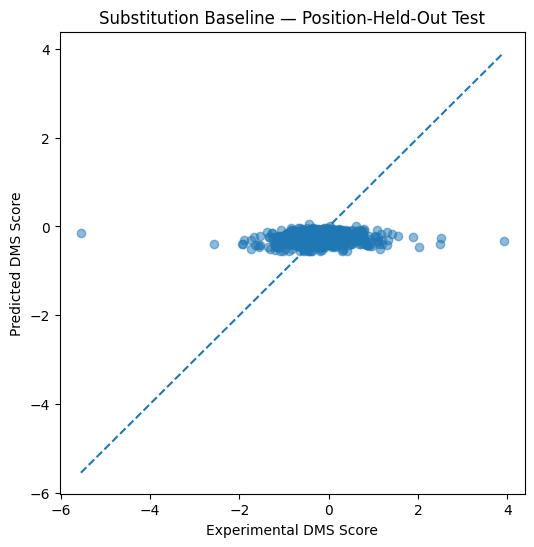

In [26]:
plt.figure(figsize=(6, 6))

plt.scatter(
    test_pos["DMS_score"],
    substitution_test_pred,
    alpha=0.5
)

min_value = min(
    test_pos["DMS_score"].min(),
    substitution_test_pred.min()
)

max_value = max(
    test_pos["DMS_score"].max(),
    substitution_test_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Experimental DMS Score")
plt.ylabel("Predicted DMS Score")
plt.title("Substitution Baseline — Position-Held-Out Test")

plt.show()

In [27]:
random_substitution_model = build_substitution_model(
    alpha=1.0
)

random_substitution_model.fit(
    train_rand[["substitution"]],
    train_rand["DMS_score"]
)

random_substitution_test_pred = (
    random_substitution_model.predict(
        test_rand[["substitution"]]
    )
)

random_substitution_test_metrics = regression_metrics(
    test_rand["DMS_score"],
    random_substitution_test_pred
)

print("Random split — substitution baseline")

for key, value in random_substitution_test_metrics.items():
    print(f"{key}: {value:.4f}")

Random split — substitution baseline
RMSE: 0.6413
MAE: 0.4263
Pearson: 0.1363
Spearman: 0.1715
R2: 0.0140


In [28]:
random_position_model = build_position_substitution_model(
    alpha=1.0
)

random_position_model.fit(
    train_rand[
        [
            "substitution",
            "position"
        ]
    ],
    train_rand["DMS_score"]
)

random_position_test_pred = (
    random_position_model.predict(
        test_rand[
            [
                "substitution",
                "position"
            ]
        ]
    )
)

random_position_test_metrics = regression_metrics(
    test_rand["DMS_score"],
    random_position_test_pred
)

print("Random split — substitution + position")

for key, value in random_position_test_metrics.items():
    print(f"{key}: {value:.4f}")

Random split — substitution + position
RMSE: 0.6407
MAE: 0.4264
Pearson: 0.1424
Spearman: 0.1731
R2: 0.0160


In [29]:
comparison = pd.DataFrame([
    {
        "Split": "Position-held-out",
        "Model": "Mean",
        **mean_test_metrics
    },
    {
        "Split": "Position-held-out",
        "Model": "Substitution",
        **substitution_test_metrics
    },
    {
        "Split": "Position-held-out",
        "Model": "Substitution + Position",
        **position_test_metrics
    },
    {
        "Split": "Random mutation",
        "Model": "Substitution",
        **random_substitution_test_metrics
    },
    {
        "Split": "Random mutation",
        "Model": "Substitution + Position",
        **random_position_test_metrics
    }
])

display(
    comparison.round(4)
)

,Split,Model,RMSE,MAE,Pearson,Spearman,R2
0,Position-held-out,Mean,0.5855,0.3968,NaN,NaN,-0.0000
1,Position-held-out,Substitution,0.5869,0.3958,0.0887,0.1353,-0.0047
2,Position-held-out,Substitution + Position,0.5881,0.3964,0.0813,0.1186,-0.0089
3,Random mutation,Substitution,0.6413,0.4263,0.1363,0.1715,0.0140
4,Random mutation,Substitution + Position,0.6407,0.4264,0.1424,0.1731,0.0160
